In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/race_results.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nSample data:")
df.head()

Shape: (10638, 13)

Columns: ['year', 'round', 'circuit_id', 'race_name', 'date', 'driver_id', 'driver_name', 'constructor', 'grid', 'position', 'points', 'status', 'laps']

Data types:
 year             int64
round            int64
circuit_id      object
race_name       object
date            object
driver_id       object
driver_name     object
constructor     object
grid             int64
position        object
points         float64
status          object
laps             int64
dtype: object

Missing values:
 year           0
round          0
circuit_id     0
race_name      0
date           0
driver_id      0
driver_name    0
constructor    0
grid           0
position       0
points         0
status         0
laps           0
dtype: int64

Sample data:


,year,round,circuit_id,race_name,date,driver_id,driver_name,constructor,grid,position,points,status,laps
0,2000,1,albert_park,Australian Grand Prix,2000-03-12,michael_schumacher,Michael Schumacher,ferrari,3,1,10.0,Finished,58
1,2000,1,albert_park,Australian Grand Prix,2000-03-12,barrichello,Rubens Barrichello,ferrari,4,2,6.0,Finished,58
2,2000,1,albert_park,Australian Grand Prix,2000-03-12,ralf_schumacher,Ralf Schumacher,williams,11,3,4.0,Finished,58
3,2000,1,albert_park,Australian Grand Prix,2000-03-12,villeneuve,Jacques Villeneuve,bar,8,4,3.0,Finished,58
4,2000,1,albert_park,Australian Grand Prix,2000-03-12,fisichella,Giancarlo Fisichella,benetton,9,5,2.0,Finished,58


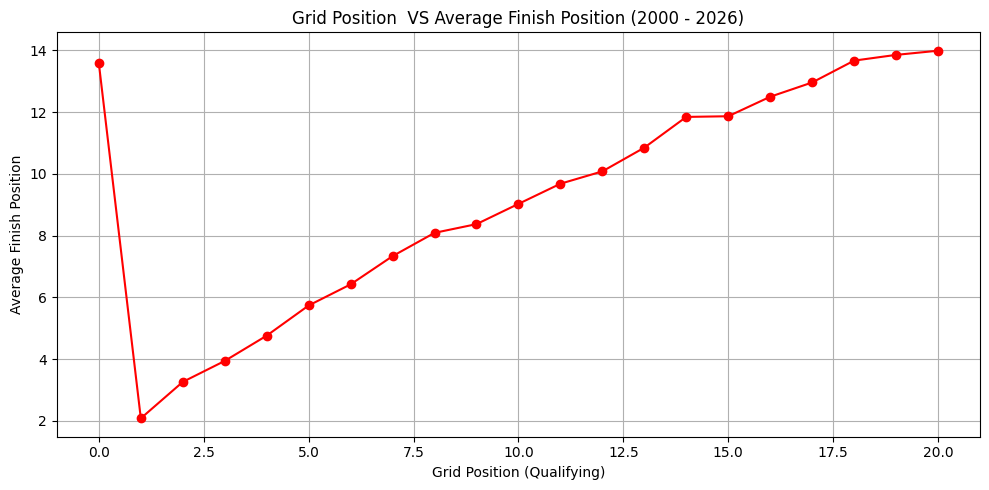

In [2]:
finished = df[df['position'].str.isnumeric()].copy()
finished['position'] = finished['position'].astype(int)

grid_vs_finish = finished.groupby('grid')['position'].mean().reset_index()
grid_vs_finish = grid_vs_finish[grid_vs_finish['grid'] <= 20]

plt.figure(figsize=(10, 5))
plt.plot(grid_vs_finish['grid'], grid_vs_finish['position'], marker='o', color='red')
plt.xlabel('Grid Position (Qualifying)')
plt.ylabel('Average Finish Position')
plt.title('Grid Position  VS Average Finish Position (2000 - 2026)')
plt.grid(True)
plt.tight_layout()
plt.show()

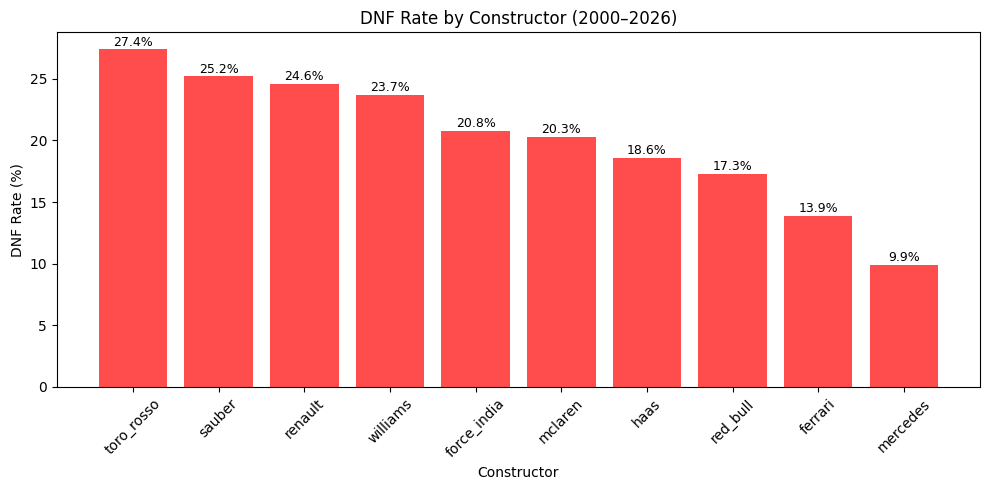

   constructor  dnf_pct
0   toro_rosso     27.4
1       sauber     25.2
2      renault     24.6
3     williams     23.7
4  force_india     20.8
5      mclaren     20.3
6         haas     18.6
7     red_bull     17.3
8      ferrari     13.9
9     mercedes      9.9


In [4]:
# DNF rate by constructor (top 10 constructors by race entries)
finished_or_dnf = df.copy()
finished_or_dnf['is_dnf'] = ~finished_or_dnf['status'].str.contains('Finished|Lap', na=False)

# get top 10 constructors by number of races
top_constructors = finished_or_dnf['constructor'].value_counts().head(10).index

dnf_rate = (
    finished_or_dnf[finished_or_dnf['constructor'].isin(top_constructors)]
    .groupby('constructor')['is_dnf']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
dnf_rate['dnf_pct'] = (dnf_rate['is_dnf'] * 100).round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(dnf_rate['constructor'], dnf_rate['dnf_pct'], color='red', alpha=0.7)
plt.xlabel('Constructor')
plt.ylabel('DNF Rate (%)')
plt.title('DNF Rate by Constructor (2000–2026)')
plt.xticks(rotation=45)

# add percentage labels on top of each bar
for bar, val in zip(bars, dnf_rate['dnf_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(dnf_rate[['constructor', 'dnf_pct']])

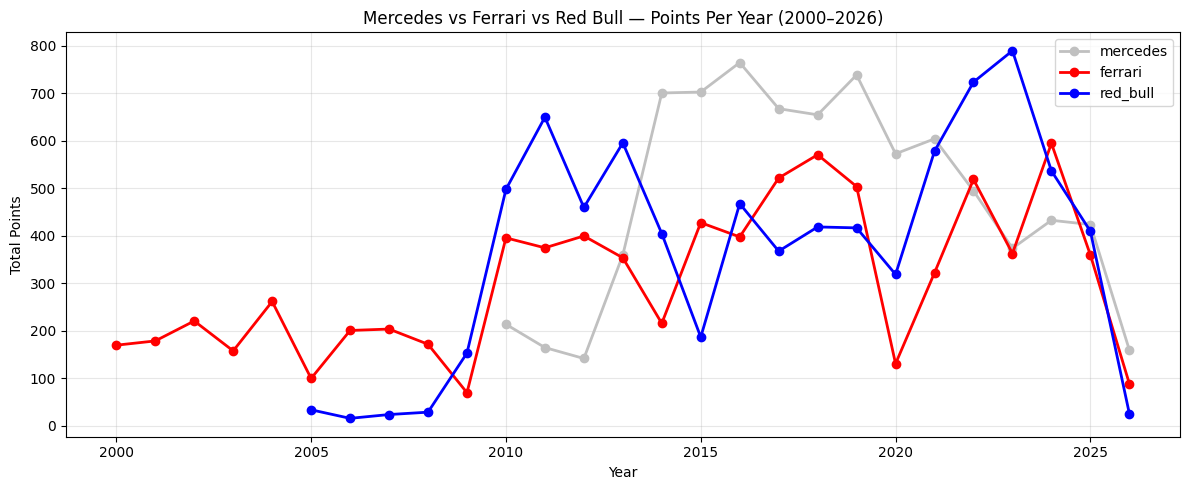

In [5]:
top3 = ['mercedes', 'ferrari', 'red_bull']
team_year = (
    df[df['constructor'].isin(top3)].groupby(['year', 'constructor'])['points'].sum().reset_index()
)
plt.figure(figsize=(12, 5))
for team, color in zip(top3, ['silver', 'red', 'blue']):
    data = team_year[team_year["constructor"]==team]
    plt.plot(data['year'], data['points'], marker='o', label=team, color=color, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Total Points')
plt.title('Mercedes vs Ferrari vs Red Bull — Points Per Year (2000–2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()